# Week 2 — Notebook 2: Technical Indicators

Implement **10 technical indicators** from scratch using only `pandas` and `numpy`.
No `ta`, `ta-lib`, or similar libraries — every value must come from the OHLCV columns.

These features are what the LSTM model will consume in later weeks.
The final cell saves a complete feature CSV to `data/processed/`.

> Implement every TODO using the mathematical formula given.

## 0. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

import os
import math

BASE_DIR      = Path('D:/Projects/lstm-trading-soc/Week2')
RAW_DIR       = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def safe_symbol(s: str) -> str:
    return s.replace('^','').replace('.','_').replace('=','_').replace('-','_')

In [2]:
# TODO 0.1 — Load a symbol from RAW_DIR
# Use 'SPY' or any symbol you downloaded in Notebook 1.
# - parse 'date' as datetime index, sort ascending
# - ensure columns: open, high, low, close, volume (all lowercase)
# - replace 0-volume rows with NaN

symbol = 'nvda'
df = pd.read_csv(os.path.join(RAW_DIR,symbol+'.csv'))
df['date'] = pd.to_datetime(df['date'])
df.set_index('date',inplace=True)
df.columns =['adj_close','close','high','low','open','volume','symbol']
df.loc[df['volume'] == 0,'volume'] = np.nan


In [3]:
# Run this after TODO 0.1 is complete

close  = df['close']
high   = df['high']
low    = df['low']
volume = df['volume']

In [4]:
# TODO 0.2 — Compute base return features needed for the model
# These are not indicators, but inputs the LSTM will use directly.
#
return_1     = close.pct_change(1)
return_5     = close.pct_change(5)
log_return_1 = np.log(1+return_1)

df['return_1']     = return_1
df['return_5']     = return_5
df['log_return_1'] = log_return_1

## 1. Simple Moving Average (SMA)

Smooths price noise and reveals the prevailing trend direction. Price above SMA → uptrend; below → downtrend.

$$\text{SMA}_n(t) = \frac{1}{n}\sum_{i=0}^{n-1}C_{t-i}$$

We also need the **ratio** of close to SMA, which tells the model how far price has stretched from its average:

$$\text{sma\_ratio}_n = \frac{C_t}{\text{SMA}_n(t)} - 1$$

In [5]:
# TODO 1.1 — Compute SMA_20, SMA_50, SMA_200
#             and sma_ratio_20, sma_ratio_50

df['sma_20']      = close.rolling(window=20).mean()
df['sma_50']      = close.rolling(window=50).mean()
df['sma_200']     = close.rolling(window=200).mean()
df['sma_ratio_20'] = (close/df['sma_20'])-1
df['sma_ratio_50'] = (close/df['sma_50'])-1

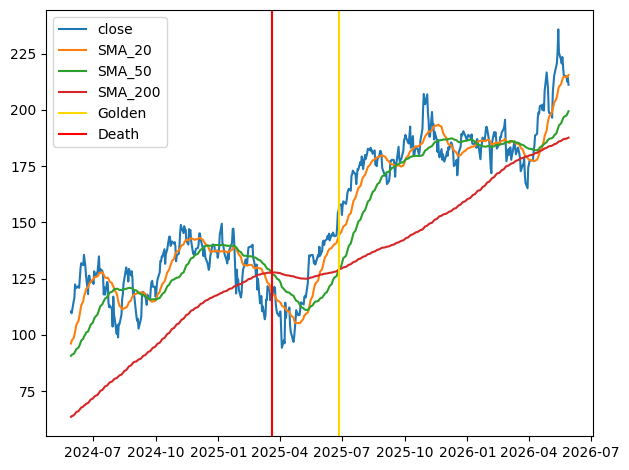

In [6]:
# TODO 1.2 — Plot close + SMA_20 + SMA_50 (last 2 years only)
# Mark Golden Cross (SMA_50 crosses above SMA_200) and Death Cross as vertical lines
# Hint: a cross occurs when the sign of (sma_50 - sma_200) changes

cutoff_date = df.index.max()-pd.DateOffset(years=2)
recent = df.loc[df.index>cutoff_date]

diff = recent['sma_50'] - recent['sma_200']
cross = diff*diff.shift(1)<0

golden = recent.index[(diff>0) & cross]
death  = recent.index[(diff<0) & cross]

# Plot Graph
plt.plot(recent['close'],label='close')
plt.plot(recent['sma_20'],label='SMA_20')
plt.plot(recent['sma_50'],label='SMA_50')
plt.plot(recent['sma_200'],label='SMA_200')
for d in golden:
    plt.axvline(d,label='Golden',color='gold')
for d in death:
    plt.axvline(d,label='Death',color='red')
plt.tight_layout()
plt.legend()
plt.show()

## 2. Exponential Moving Average (EMA)

Assigns exponentially decaying weights to past prices — more reactive to recent moves than SMA.

$$k = \frac{2}{n+1}, \qquad \text{EMA}(t) = C_t \cdot k + \text{EMA}(t-1)\cdot(1-k)$$

Also compute:
$$\text{ema\_ratio}_{20} = \frac{C_t}{\text{EMA}_{20}(t)} - 1$$

In [7]:
# TODO 2.1 — Compute EMA_12, EMA_20, EMA_26 and ema_ratio_20

df['ema_12']       = df['close'].ewm(span=12).mean()
df['ema_20']       = df['close'].ewm(span=20).mean()
df['ema_26']       = df['close'].ewm(span=26).mean()
df['ema_ratio_20'] = (df['close']/df['ema_20'])-1

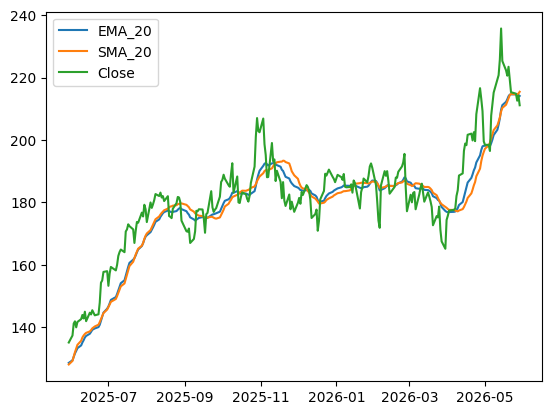

In [8]:
# TODO 2.2 — On a single chart, plot Close + SMA_20 + EMA_20 for the last 365 days
# Visually confirm: EMA reacts faster to price turns than SMA

cutoff_date = df.index.max() - pd.DateOffset(years=1)
recent = df.loc[df.index > cutoff_date]

plt.plot(recent['ema_20'],label='EMA_20')
plt.plot(recent['sma_20'],label='SMA_20')
plt.plot(recent['close'],label='Close')
plt.legend()
plt.show()


## 3. Relative Strength Index (RSI)

Momentum oscillator bounded in $[0, 100]$. Measures the ratio of average gains to average losses over $n$ days.

$$\Delta_t = C_t - C_{t-1}$$
$$G_t = \max(\Delta_t,\,0), \quad L_t = |\min(\Delta_t,\,0)|$$
$$\overline{G}_n = \text{EMA}_n(G), \quad \overline{L}_n = \text{EMA}_n(L)$$
$$RS = \frac{\overline{G}_n}{\overline{L}_n}, \quad \text{RSI} = 100 - \frac{100}{1 + RS}$$

Wilder's RSI uses $\alpha = 1/n$ (i.e. `com = n-1`) rather than the standard EMA span. RSI $> 70$: overbought. RSI $< 30$: oversold. Normalise to $[0, 1]$ before storing as a model feature.

In [9]:
# TODO 3.1 — Implement RSI with window=14; store normalised (÷100) as 'rsi_14'
# Use Wilder smoothing: ewm(com=n-1, adjust=False)

delta    = df['close'].diff()
gain     = delta.clip(lower=0)
loss     = delta.clip(upper=0).abs()
avg_gain = gain.ewm(com=13,adjust=False).mean()
avg_loss = loss.ewm(com=13,adjust=False).mean()
rs       = avg_gain/avg_loss
df['rsi_14'] = 1-(1/(1+rs))

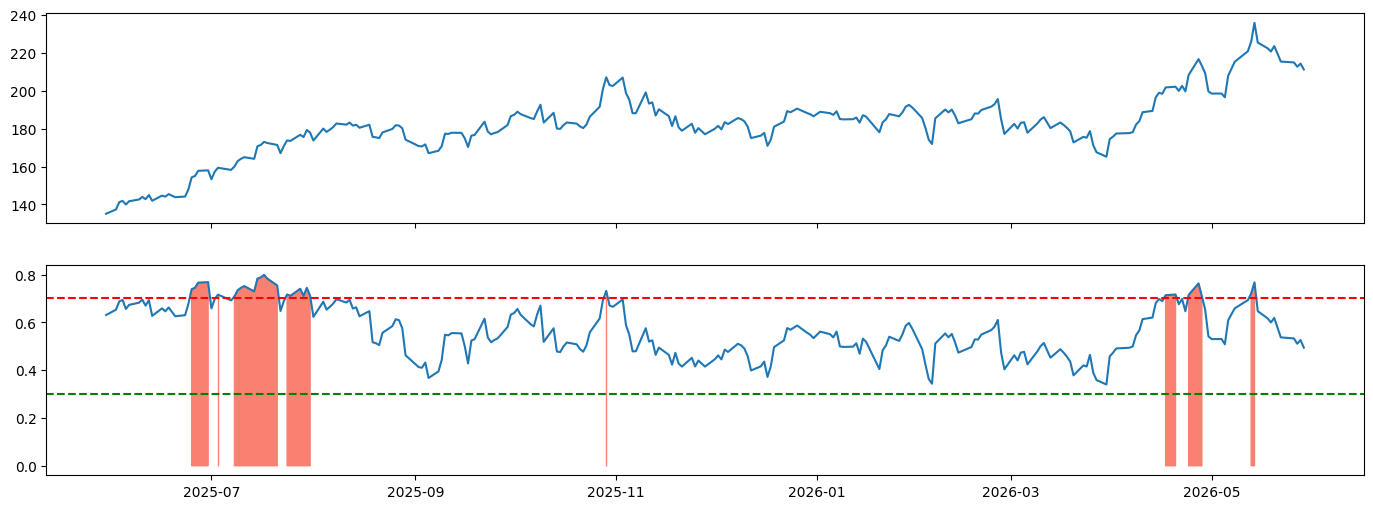

In [10]:
# TODO 3.2 — Two-panel chart: close (top) + RSI (bottom), sharex=True
# Dashed lines at 0.70 and 0.30; shade overbought in light red, oversold in light green
recent = df.loc[df.index > cutoff_date]

fig, axs = plt.subplots(2,1,sharex=True, figsize=(17,6))
axs[0].plot(recent['close'],label='close')
axs[1].plot(recent['rsi_14'],label='RSI')
axs[1].fill_between(recent.index,recent['rsi_14'],where=(recent['rsi_14']>0.7), color='salmon')
axs[1].fill_between(recent.index,recent['rsi_14'],where=(recent['rsi_14']<0.3), color='lightgreen')

axs[1].axhline(0.7, linestyle='--', color='red')

axs[1].axhline(0.3, linestyle='--', color='green')

plt.show()


## 4. MACD

Captures the convergence/divergence of two EMAs. Three outputs:

$$\text{MACD Line} = \text{EMA}_{12} - \text{EMA}_{26}$$
$$\text{Signal Line} = \text{EMA}_9(\text{MACD Line})$$
$$\text{Histogram} = \text{MACD Line} - \text{Signal Line}$$

Histogram sign-change → momentum shift. MACD crossing above Signal → bullish.

In [11]:
# TODO 4.1 — Compute macd, macd_signal, macd_hist using ema_12 and ema_26

df['macd']        = df['ema_12']-df['ema_26']
df['macd_signal'] = df['macd'].ewm(span=9).mean()
df['macd_hist']   = df['macd']-df['macd_signal']

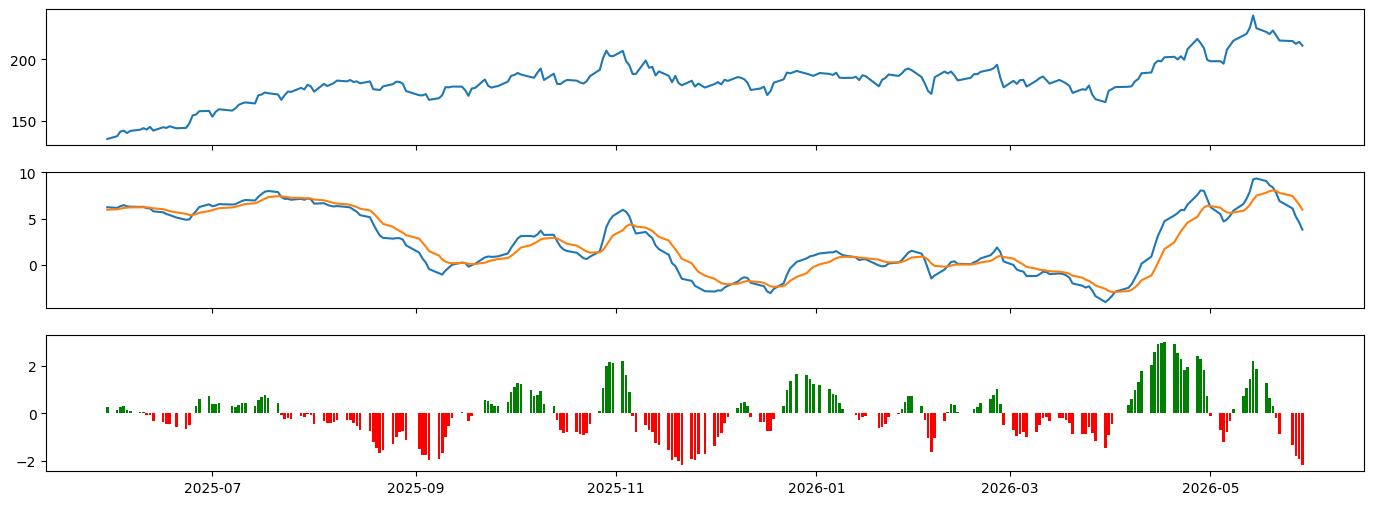

In [12]:
# TODO 4.2 — Three-panel chart: close | macd+signal | histogram coloured by sign
recent = df.loc[df.index > cutoff_date]

fig, axs = plt.subplots(3,1,sharex=True,figsize=(17,6))
axs[0].plot(recent['close'],label='close')
axs[1].plot(recent['macd'],label='MACD')
axs[1].plot(recent['macd_signal'],label='Signal Line')

bullish = recent.loc[recent['macd_hist'] > 0 ]
bearish = recent.loc[recent['macd_hist'] < 0 ]

axs[2].bar(bullish.index,bullish['macd_hist'],color='green')
axs[2].bar(bearish.index,bearish['macd_hist'],color='red')
# axs[2].axhline(0)
plt.show()


## 5. Bollinger Bands

Places volatility-scaled envelopes around the 20-day SMA.

$$\text{Upper} = \text{SMA}_{20} + k\cdot\sigma_{20}, \quad \text{Lower} = \text{SMA}_{20} - k\cdot\sigma_{20}, \quad k=2$$

Two derived features used as model inputs:

| Feature | Formula |
|---|---|
| **BB Width** | $\frac{\text{Upper} - \text{Lower}}{C_t}$ — proxy for volatility |
| **%B** | $\frac{C_t - \text{Lower}}{\text{Upper} - \text{Lower}}$ — position within bands |

In [13]:
# TODO 5 — Compute bb_upper, bb_lower, bb_width, bb_pct_b

rolling_std    = df['close'].rolling(window=20).std()
df['bb_upper'] = df['sma_20']+2*rolling_std
df['bb_lower'] = df['sma_20']-2*rolling_std
df['bb_width'] = (df['bb_upper']-df['bb_lower'])/df['close']
df['bb_pct_b'] = (df['close']-df['bb_lower'])/(df['bb_upper']-df['bb_lower'])   
# clip to [0, 1] optional but useful
df['bb_pct_b'] = df['bb_pct_b'].clip(lower=0,upper=1)

## 6. Rate of Change (ROC)

Measures momentum as the percentage change over $n$ periods.

$$\text{ROC}_n(t) = \frac{C_t - C_{t-n}}{C_{t-n}} \times 100$$

Compute for $n = 5$ and $n = 10$.

In [14]:
# TODO 6 — Compute roc_5 and roc_10

df['roc_5']  = df['close'].pct_change(5)*100
df['roc_10'] = df['close'].pct_change(10)*100

## 7. Average True Range (ATR)

Measures volatility using all three price extremes. Unlike rolling return std, ATR accounts for overnight gaps.

$$TR_t = \max\bigl(H_t - L_t,\;|H_t - C_{t-1}|,\;|L_t - C_{t-1}|\bigr)$$

$$\text{ATR}_{14}(t) = \text{EMA}_{14}(TR) \quad\text{(Wilder smoothing: }\alpha = 1/n\text{)}$$

Normalise by close to make it comparable across symbols:
$$\text{atr\_ratio} = \frac{\text{ATR}_{14}}{C_t}$$

In [15]:
# TODO 7 — Compute true_range, atr_14, atr_ratio
# Use Wilder smoothing (ewm with com=13, adjust=False)

prev_close = df['close'].shift(1)
temp = pd.DataFrame()
temp['1'] = df['high']-df['low']
temp['2'] = (df['high']-df['close'].shift(1)).abs()
temp['3'] = (df['low'] - df['close'].shift(1)).abs()
true_range = temp[['1','2','3']].max(axis=1)
df['atr_14']    = true_range.ewm(com=13).mean()
df['atr_ratio'] = df['atr_14']/df['close']

## 8. Stochastic Oscillator (%K and %D)

Compares the closing price to the price range over a lookback window.

$$\%K_n(t) = \frac{C_t - \min_n(L)}{\max_n(H) - \min_n(L)} \times 100$$

$$\%D = \text{SMA}_3(\%K) \quad \text{(signal smoothing)}$$

Use $n = 14$. Normalise both to $[0, 1]$. Store as `stoch_k` and `stoch_d`.

In [16]:
# TODO 8.1 — Compute stoch_k and stoch_d

lowest_low   = df['low'].min()
highest_high = df['high'].max()
df['stoch_k'] = (df['close']-lowest_low)/(highest_high-lowest_low)
df['stoch_d'] = df['stoch_k'].rolling(window=14).mean()

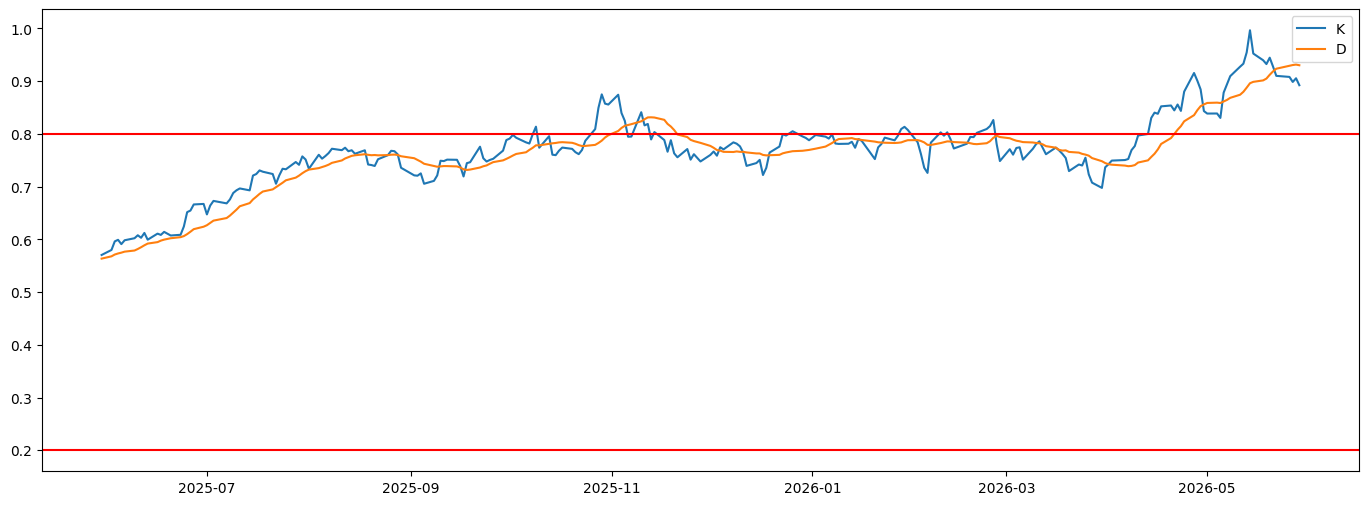

In [17]:
# TODO 8.2 — Plot stoch_k and stoch_d, last 365 days
# Mark 0.80 and 0.20 thresholds
# When %K crosses above %D from below the oversold zone → classic buy signal
recent = df.loc[df.index>cutoff_date]
plt.figure(figsize=(17,6))
plt.plot(recent['stoch_k'],label='K')
plt.plot(recent['stoch_d'],label='D')
plt.axhline(0.8,color='red')
plt.axhline(0.2,color='red')
plt.legend()
plt.show()


## 9. On-Balance Volume (OBV)

Cumulative volume indicator — adds volume on up-days, subtracts it on down-days. Used to detect whether volume confirms or diverges from a price trend.

$$\text{OBV}(t) = \text{OBV}(t-1) + \begin{cases} +V_t & C_t > C_{t-1} \\ -V_t & C_t < C_{t-1} \\ 0 & C_t = C_{t-1} \end{cases}$$

Store the **percentage change** of OBV as the model feature: $\text{obv\_change} = \frac{\text{OBV}(t) - \text{OBV}(t-1)}{|\text{OBV}(t-1)|}$

In [18]:
# TODO 9 — Compute obv and obv_change
# np.sign(close.diff()) gives +1 / 0 / -1 for each day's direction

direction       = np.sign(close.diff())
df['obv'] = volume
df['obv']       = df['obv'].shift(1)+direction*volume
df['obv_change']= df['obv'].pct_change()

## 10. Volume-Weighted Average Price (VWAP)

The price level weighted by volume — a fair-value benchmark widely used by institutional traders.

We compute a **rolling 20-day VWAP** using the typical price:

$$P_{\text{typ}}(t) = \frac{H_t + L_t + C_t}{3}$$

$$\text{VWAP}_{20}(t) = \frac{\sum_{i=0}^{19} P_{\text{typ}}(t{-}i)\cdot V_{t{-}i}}{\sum_{i=0}^{19} V_{t{-}i}}$$

Normalise: $\text{vwap\_ratio} = C_t / \text{VWAP} - 1$

In [19]:
# TODO 10 — Compute rolling VWAP (20-day) and vwap_ratio

typical_price   = (df['high']+df['low']+df['close'])/3
tp_vol          = typical_price*volume
df['vwap']       = tp_vol.rolling(window=20).sum()/volume.rolling(window=20).sum()
df['vwap_ratio'] = (close/df['vwap'])-1

## 11. Build & Save the Feature Dataset

Combine all indicators into a clean DataFrame and save to `data/processed/`.
This CSV will be loaded directly by the model notebooks in later weeks.

In [20]:
FEATURE_COLUMNS = [
    'return_1', 'return_5', 'log_return_1',
    'sma_ratio_20', 'sma_ratio_50',
    'ema_ratio_20',
    'rsi_14',
    'macd', 'macd_signal',
    'roc_5', 'roc_10',
    'bb_width', 'bb_pct_b',
    'atr_ratio',
    'stoch_k', 'stoch_d',
    'obv_change',
    'vwap_ratio',
    'future_return',
    'target_direction',
]

In [21]:
# TODO 11.1 — Add target columns, clean, and save
future_return    = (close.shift(-1)/close)-1                    #(close shifted -1 divided by close, minus 1)
target_direction = pd.DataFrame(np.where(future_return>0,1,0))                #1 if future_return > 0, else 0
target_direction.index = df.index
#
# Then:
#   1. Replace inf / -inf with NaN
#   2. Drop rows where ANY required column is NaN
#   3. Reset index so 'date' becomes a regular column again
#   4. Save to  PROCESSED_DIR / f'{safe_symbol(SYMBOL)}_features.csv'
#   5. Print the output path and shape; show .describe() of required columns
df['future_return']    = future_return
df['target_direction'] = target_direction

required = FEATURE_COLUMNS
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.reset_index()
df_clean = df.dropna()
filename = symbol+'.csv'
out_path = PROCESSED_DIR
df_clean.to_csv(os.path.join(out_path,filename))
print(df_clean)
df_clean[required].describe().round(4)

             adj_close       close        high         low        open  \
date                                                                     
2015-10-16    0.676970    0.696500    0.703000    0.686250    0.688000   
2015-10-19    0.675755    0.695250    0.702000    0.687250    0.698750   
2015-10-20    0.674783    0.694250    0.697500    0.687000    0.692250   
2015-10-21    0.666035    0.685250    0.702750    0.684000    0.698500   
2015-10-22    0.690091    0.710000    0.712250    0.692250    0.693250   
...                ...         ...         ...         ...         ...   
2026-05-21  219.509995  219.509995  227.399994  217.929993  222.289993   
2026-05-22  215.330002  215.330002  221.009995  214.800003  220.899994   
2026-05-26  214.860001  214.860001  218.179993  212.000000  216.539993   
2026-05-27  212.600006  212.600006  214.149994  208.779999  214.119995   
2026-05-28  214.250000  214.250000  215.520004  211.220001  211.279999   

                 volume symbol  retur

,return_1,return_5,log_return_1,sma_ratio_20,sma_ratio_50,ema_ratio_20,rsi_14,macd,macd_signal,roc_5,roc_10,bb_width,bb_pct_b,atr_ratio,stoch_k,stoch_d,obv_change,vwap_ratio,future_return,target_direction
count,2668.0000,2668.0000,2668.0000,2668.0000,2668.0000,2668.0000,2668.0000,2668.0000,2668.0000,2668.0000,2668.0000,2668.0000,2668.0000,2668.0000,2668.0000,2668.0000,2668.0000,2668.0000,2668.0000,2668.0000
mean,0.0026,0.0131,0.0022,0.0221,0.0581,0.0205,0.5652,0.5455,0.5358,1.3058,2.6399,0.1963,0.6025,0.0378,0.1729,0.1706,-3.5671,0.0224,0.0026,0.5439
std,0.0310,0.0663,0.0308,0.0728,0.1213,0.0625,0.1251,1.8986,1.7792,6.6312,9.4243,0.1018,0.2992,0.0134,0.2469,0.2439,102.5931,0.0687,0.0310,0.4982
min,-0.1876,-0.2836,-0.2077,-0.2774,-0.3912,-0.2819,0.1883,-6.2601,-4.7446,-28.3561,-32.3121,0.0453,0.0000,0.0189,0.0007,0.0007,-3916.2059,-0.2605,-0.1876,0.0000
25%,-0.0130,-0.0261,-0.0131,-0.0192,-0.0116,-0.0122,0.4786,-0.0308,-0.0227,-2.6067,-2.9365,0.1245,0.3711,0.0283,0.0168,0.0167,-1.2108,-0.0179,-0.0130,0.0000
50%,0.0027,0.0132,0.0027,0.0239,0.0639,0.0242,0.5660,0.0954,0.0959,1.3152,2.6304,0.1733,0.6669,0.0342,0.0544,0.0543,-0.7704,0.0262,0.0027,1.0000
75%,0.0181,0.0495,0.0180,0.0651,0.1352,0.0594,0.6576,0.5664,0.5130,4.9517,8.1983,0.2380,0.8474,0.0434,0.1911,0.1876,0.1083,0.0676,0.0181,1.0000
max,0.2981,0.3633,0.2609,0.3012,0.4191,0.2575,0.8917,9.7741,8.8561,36.3288,38.9405,0.7369,1.0000,0.1062,0.9966,0.9315,672.8664,0.2369,0.2981,1.0000


In [22]:
# TODO 11.2 (Challenge) — Run the full pipeline for atleast one downloaded symbols
# To process for all symbol change the symbol above rerun all cells to get features of that symbol.
# Loop over every CSV in RAW_DIR, compute all indicators, save to PROCESSED_DIR.
# Wrap each symbol in try/except so one failure does not stop the loop.
# Print a summary table at the end with columns:
#   symbol | rows_raw | rows_processed | drop_pct
symbols = ['NSEI','BSESN','RELIANCE_NS','TCS_NS','INFY_NS','GSPC','IXIC','SPY','AAPL','MSFT','NVDA','TSLA','BTC_USD','ETH_USD','EURUSD_X','JPY_X',]
summary = []
for sym in symbols:
    filename = sym +'.csv'
    csv_path = os.path.join(RAW_DIR,filename)
    try:
        raw       = pd.read_csv(csv_path)
        df = raw
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date',inplace=True)
        df.columns =['adj_close','close','high','low','open','volume','symbol']
        df.loc[df['volume'] == 0,'volume'] = np.nan
        close  = df['close']
        high   = df['high']
        low    = df['low']
        volume = df['volume']        
        df['return_1']     = close.pct_change(1)
        df['return_5']     = close.pct_change(5)
        df['log_return_1'] = np.log(1+return_1)

        df['sma_20']      = close.rolling(window=20).mean()
        df['sma_50']      = close.rolling(window=50).mean()
        df['sma_200']     = close.rolling(window=200).mean()
        df['sma_ratio_20'] = (close/df['sma_20'])-1
        df['sma_ratio_50'] = (close/df['sma_50'])-1

        df['ema_12']       = df['close'].ewm(span=12).mean()
        df['ema_20']       = df['close'].ewm(span=20).mean()
        df['ema_26']       = df['close'].ewm(span=26).mean()
        df['ema_ratio_20'] = (df['close']/df['ema_20'])-1

        delta    = df['close'].diff()
        gain     = delta.clip(lower=0)
        loss     = delta.clip(upper=0).abs()
        avg_gain = gain.ewm(com=13,adjust=False).mean()
        avg_loss = loss.ewm(com=13,adjust=False).mean()
        rs       = avg_gain/avg_loss
        df['rsi_14'] = 1-(1/(1+rs))

        df['macd']        = df['ema_12']-df['ema_26']
        df['macd_signal'] = df['macd'].ewm(span=9).mean()
        df['macd_hist']   = df['macd']-df['macd_signal']

        rolling_std    = df['close'].rolling(window=20).std()
        df['bb_upper'] = df['sma_20']+2*rolling_std
        df['bb_lower'] = df['sma_20']-2*rolling_std
        df['bb_width'] = (df['bb_upper']-df['bb_lower'])/df['close']
        df['bb_pct_b'] = (df['close']-df['bb_lower'])/(df['bb_upper']-df['bb_lower'])   
        df['bb_pct_b'] = df['bb_pct_b'].clip(lower=0,upper=1)

        df['roc_5']  = df['close'].pct_change(5)*100
        df['roc_10'] = df['close'].pct_change(10)*100

        prev_close = df['close'].shift(1)
        temp = pd.DataFrame()
        temp['1'] = df['high']-df['low']
        temp['2'] = (df['high']-df['close'].shift(1)).abs()
        temp['3'] = (df['low'] - df['close'].shift(1)).abs()
        true_range = temp[['1','2','3']].max(axis=1)
        df['atr_14']    = true_range.ewm(com=13).mean()
        df['atr_ratio'] = df['atr_14']/df['close']

        lowest_low   = df['low'].min()
        highest_high = df['high'].max()
        df['stoch_k'] = (df['close']-lowest_low)/(highest_high-lowest_low)
        df['stoch_d'] = df['stoch_k'].rolling(window=14).mean()
        direction       = np.sign(close.diff())

        df['obv'] = volume
        df['obv']       = df['obv'].shift(1)+direction*volume
        df['obv_change']= df['obv'].pct_change()

        typical_price   = (df['high']+df['low']+df['close'])/3
        tp_vol          = typical_price*volume
        df['vwap']       = tp_vol.rolling(window=20).sum()/volume.rolling(window=20).sum()
        df['vwap_ratio'] = (close/df['vwap'])-1

        future_return    = (close.shift(-1)/close)-1
        target_direction = pd.DataFrame(np.where(future_return>0,1,0))                
        target_direction.index = df.index
        df['future_return']    = future_return
        df['target_direction'] = target_direction
        required = FEATURE_COLUMNS
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df.reset_index()
        df_clean = df.dropna()  



        # ... use the computed indicators above ...
        processed = df_clean
        processed.to_csv(os.path.join(PROCESSED_DIR,filename))
        # ... save to PROCESSED_DIR ...
        summary.append({sym})
    except Exception as e:
        summary.append({'symbol': sym, 'error': str(e)})

pd.DataFrame(summary)

,0
0,NSEI
1,BSESN
2,RELIANCE_NS
3,TCS_NS
4,INFY_NS
5,GSPC
6,IXIC
7,SPY
8,AAPL
9,MSFT


---
